# EDA for Malaysia Residential Property Data

In [2]:
import pandas as pd # for data manipulation and analysis
import numpy as np
import missingno as msno # uncovering missing data patterns in datasets
import matplotlib.pyplot as plt # for plotting graph
import seaborn as sns

In [7]:
df = pd.read_csv('Malaysia Residential Property Data.csv', sep='\t', encoding='utf-8')

In [8]:
df.head()

,Property Type,District,Mukim,Scheme Name/Area,Road Name,"Month, Year of Transaction Date",Tenure,Land/Parcel Area,Unit,Main Floor Area,Unit,Unit Level,Transaction Price,Unnamed: 13
0,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Bdr Masjid Tanah,TMN BUKIT INDAH FASA 2,JLN BUKIT INDAH 6,March 2024,Freehold,374.00,sq.m,106,sq.m,,"RM470,000.00",NaN
1,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Belimbing,TMN BELIMBING HARMONI,JLN BELIMBING HARMONI,May 2023,Leasehold,234.00,sq.m,67,sq.m,,"RM483,000.00",NaN
2,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Belimbing,TMN VISTA BELIMBING,JALAN DURIAN TUNGGAL-ALOR GAJAH,April 2021,Freehold,268.00,sq.m,118,sq.m,,"RM359,000.00",NaN
3,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Belimbing,TMN VISTA BELIMBING,JALAN DURIAN TUNGGAL-ALOR GAJAH,April 2021,Freehold,268.00,sq.m,118,sq.m,,"RM435,000.00",NaN
4,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Belimbing,TMN VISTA BELIMBING,JALAN DURIAN TUNGGAL-ALOR GAJAH,April 2021,Freehold,297.00,sq.m,118,sq.m,,"RM373,000.00",NaN


In [9]:

df.dtypes

Property Type                          str
District                               str
Mukim                                  str
Scheme Name/Area                       str
Road Name                              str
Month, Year of Transaction Date        str
Tenure                                 str
Land/Parcel Area                       str
Unit                                   str
Main Floor Area                        str
Unit                                   str
Unit Level                             str
Transaction Price                      str
Unnamed: 13                        float64
dtype: object

In [13]:
df.shape

(410959, 14)

<Axes: >

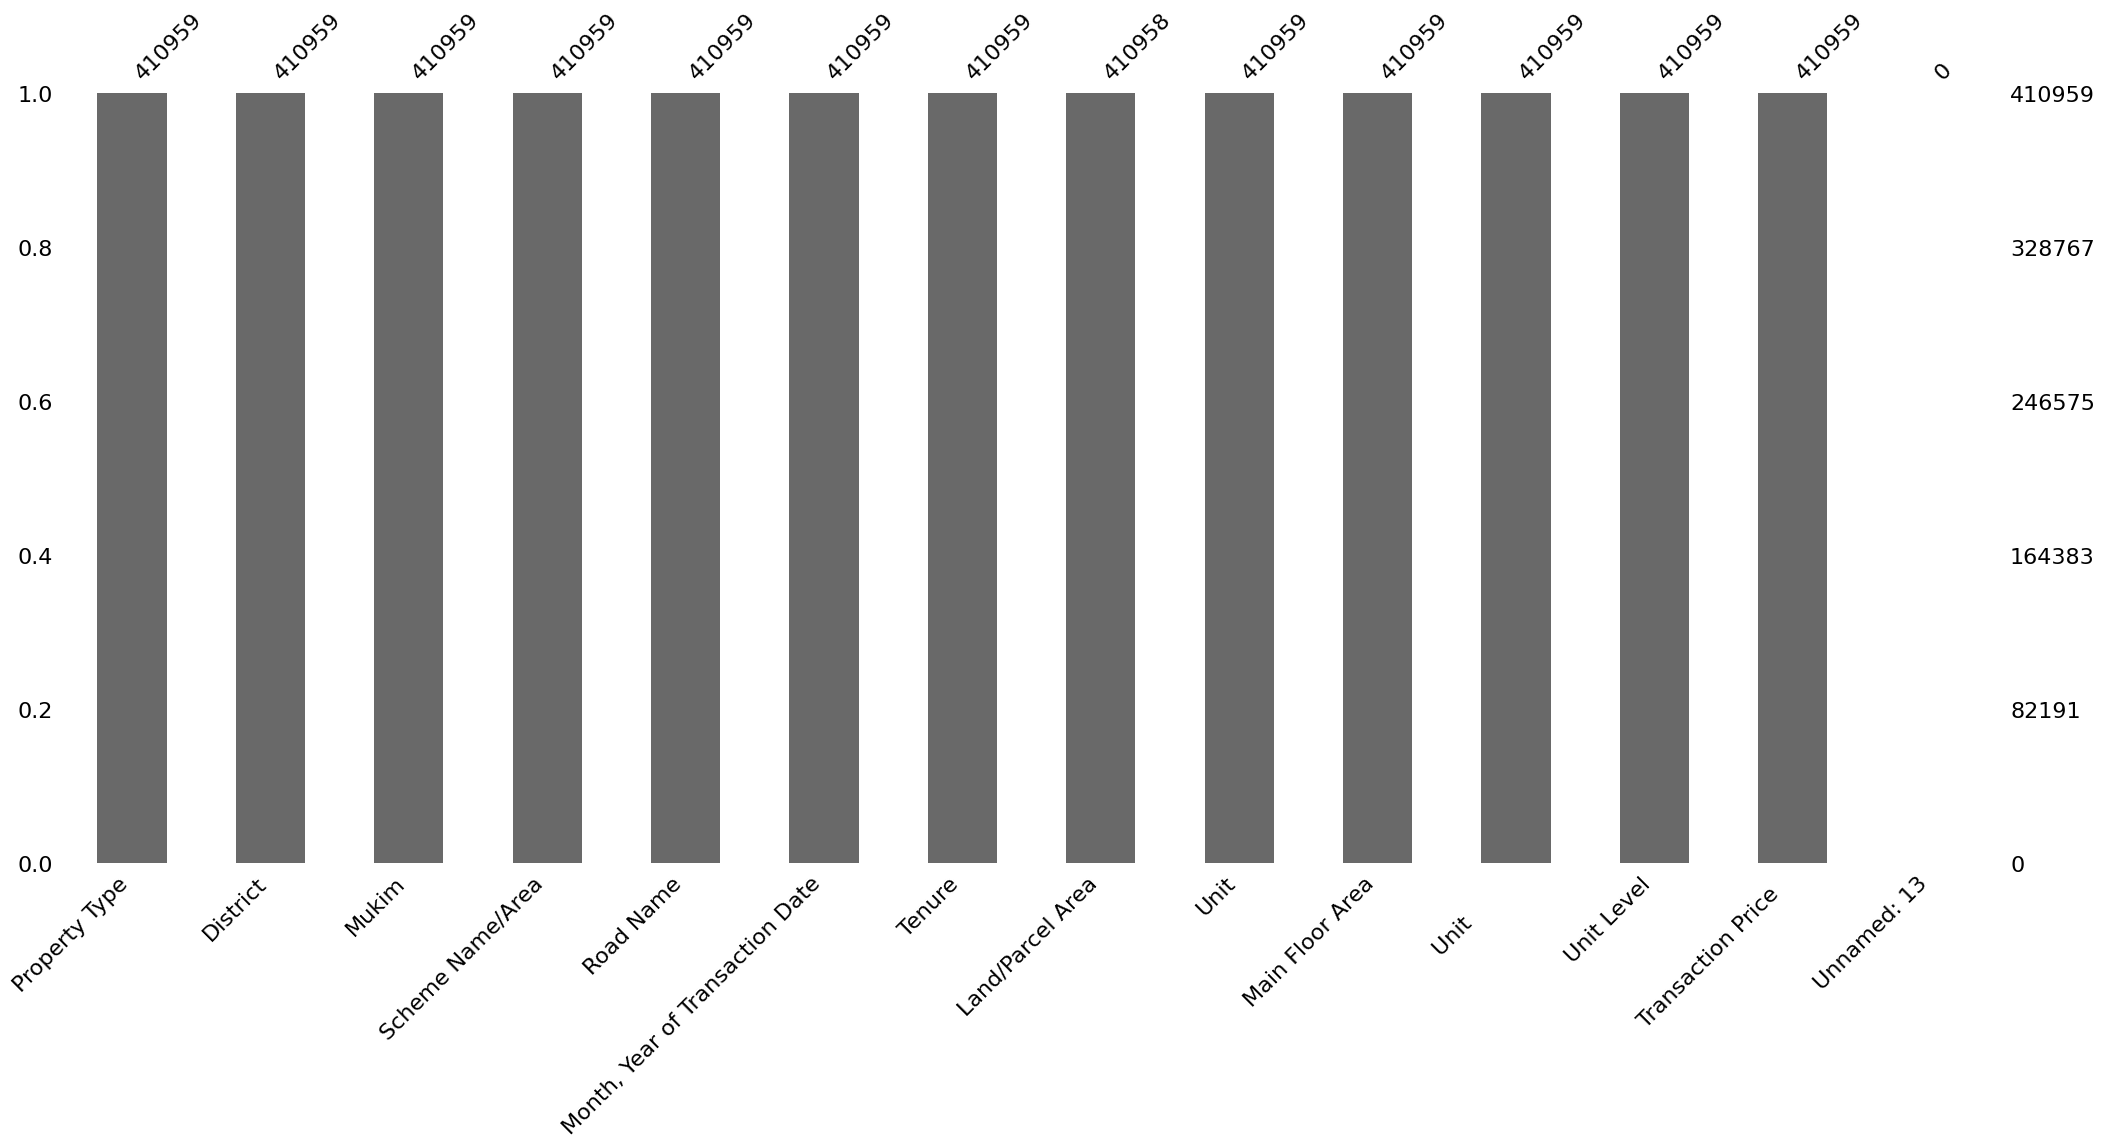

In [10]:
msno.bar(df) 

In [14]:
print("\nExisting column :\n " + f"{df.columns.tolist()}") # inspect column name, view any whitespace


Existing column :
 ['Property Type', 'District', 'Mukim', 'Scheme Name/Area', 'Road Name', 'Month, Year of Transaction Date', 'Tenure', 'Land/Parcel Area', 'Unit', 'Main Floor Area', 'Unit        ', 'Unit Level', 'Transaction Price  ', 'Unnamed: 13']


In [15]:

df.duplicated().sum() # total count of duplicate rows present in the DataFrame:

np.int64(447)

In [16]:
for i in df.columns: # checking total null values/NaN in a column
    print(i," : ",df[i].isnull().sum()) # OR print(i," : ",df[i].isna().sum())

Property Type  :  0
District  :  0
Mukim  :  0
Scheme Name/Area  :  0
Road Name  :  0
Month, Year of Transaction Date  :  0
Tenure  :  0
Land/Parcel Area  :  1
Unit  :  0
Main Floor Area  :  0
Unit          :  0
Unit Level  :  0
Transaction Price    :  0
Unnamed: 13  :  410959


**Data wrangling**

In [17]:

df.columns = df.columns.str.strip() # remove leading/trailing spaces in column names and print the output after column stripped
print("\nColumn after stripped :\n" + f"{df.columns.tolist()}\n")


Column after stripped :
['Property Type', 'District', 'Mukim', 'Scheme Name/Area', 'Road Name', 'Month, Year of Transaction Date', 'Tenure', 'Land/Parcel Area', 'Unit', 'Main Floor Area', 'Unit', 'Unit Level', 'Transaction Price', 'Unnamed: 13']



In [18]:
df = df.dropna(axis=1, how='all') # remove the entire column only if all values are NaN and print the output after removed NaN column:
print("\nResult after remove NaN column :\n"+ f"{df.columns.tolist()}")


Result after remove NaN column :
['Property Type', 'District', 'Mukim', 'Scheme Name/Area', 'Road Name', 'Month, Year of Transaction Date', 'Tenure', 'Land/Parcel Area', 'Unit', 'Main Floor Area', 'Unit', 'Unit Level', 'Transaction Price']


In [19]:
# Clean and convert 'Transaction Price' to numeric
df['Transaction Price'] = df['Transaction Price'].str.replace('RM', '', regex=False)
df['Transaction Price'] = df['Transaction Price'].str.replace(',', '', regex=False).astype(float)

print(df['Land/Parcel Area'].unique())
print(df['Land/Parcel Area'][df['Land/Parcel Area'] == ''])  # find empty strings

# Clean and convert 'Land/Parcel Area' to numeric
df['Land/Parcel Area'] = df['Land/Parcel Area'].str.replace(',', '', regex=False).astype(float)

print(df['Main Floor Area'].unique())
print(df['Main Floor Area'][df['Main Floor Area'] == ''])  # find empty strings

# Clean and convert 'Main Floor Area' to numeric
df['Main Floor Area'] = df['Main Floor Area'].str.replace('-', '', regex=False)
df['Main Floor Area'] = df['Main Floor Area'].str.replace(',', '', regex=False).replace('', np.nan).astype(float)

<StringArray>
['374.00', '234.00', '268.00', '297.00', '331.00', '387.00', '478.00',
 '490.00', '433.00', '290.00',
 ...
 '150.31',  '97.63',  '96.52',  '96.53',  '99.86',  '81.70',  '90.81',
 '132.28',  '70.29', '359.63']
Length: 17613, dtype: str
Series([], Name: Land/Parcel Area, dtype: str)
<StringArray>
[  '106',    '67',   '118',   '116',   '217',   '143',    '82',   '133',
   '117',    '93',
 ...
   '630', '1,360',   '661', '2,178', '1,755',   '707',   '610',   '561',
 '1,823',    '23']
Length: 825, dtype: str
Series([], Name: Main Floor Area, dtype: str)


In [23]:
# Convert 'Month, Year of Transaction Date' to datetime
df['Transaction Date'] = pd.to_datetime(df['Month, Year of Transaction Date'], format='%B %Y')

**Analayze data after data wrangling**

In [25]:

df.dtypes

Property Type                                 str
District                                      str
Mukim                                         str
Scheme Name/Area                              str
Road Name                                     str
Month, Year of Transaction Date               str
Tenure                                        str
Land/Parcel Area                          float64
Unit                                          str
Main Floor Area                           float64
Unit                                          str
Unit Level                                    str
Transaction Price                         float64
Transaction Date                   datetime64[us]
dtype: object

<Axes: >

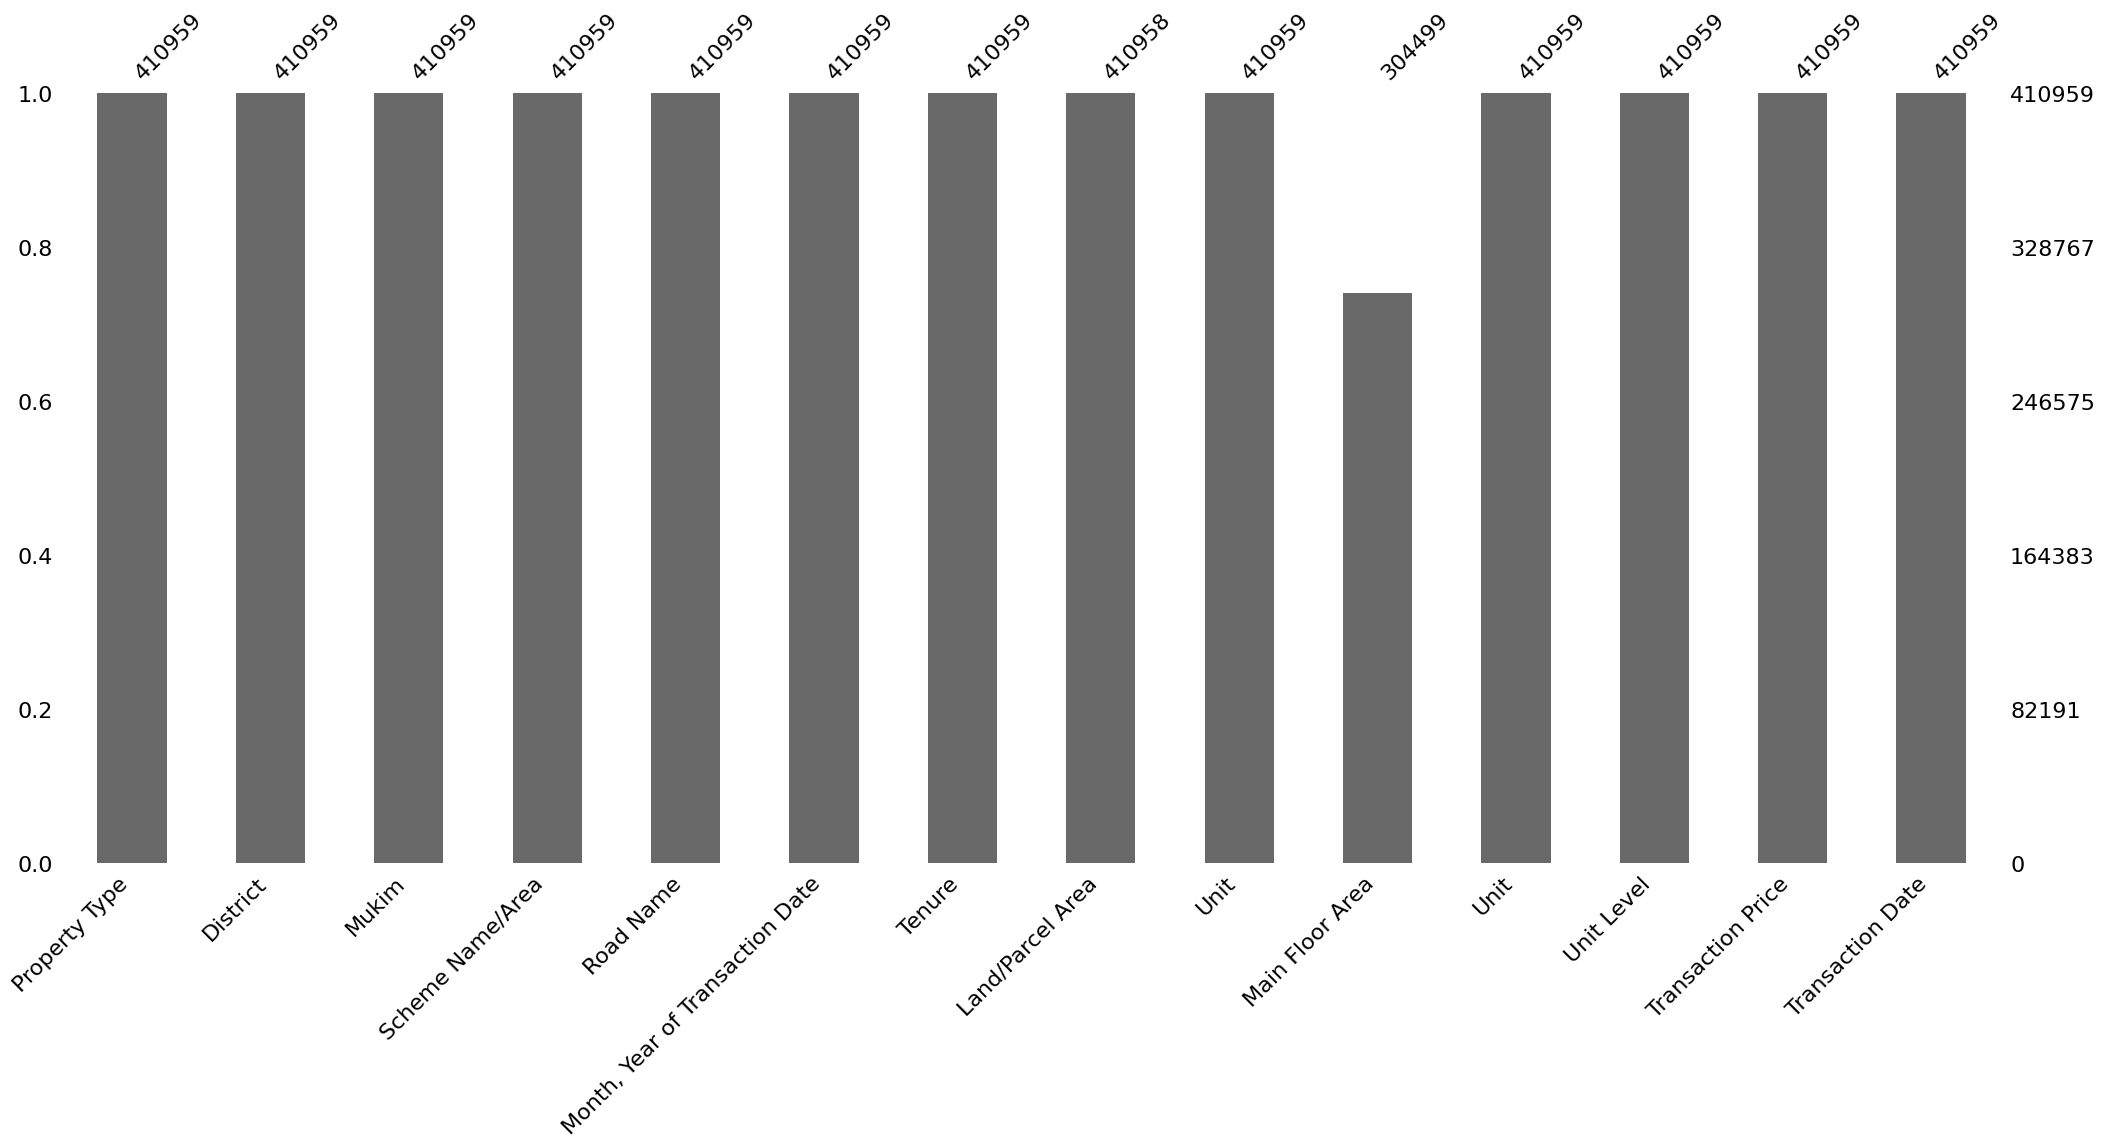

In [26]:
msno.bar(df) # visualizing missing numeric data with bar chart (missingno library)

<Axes: >

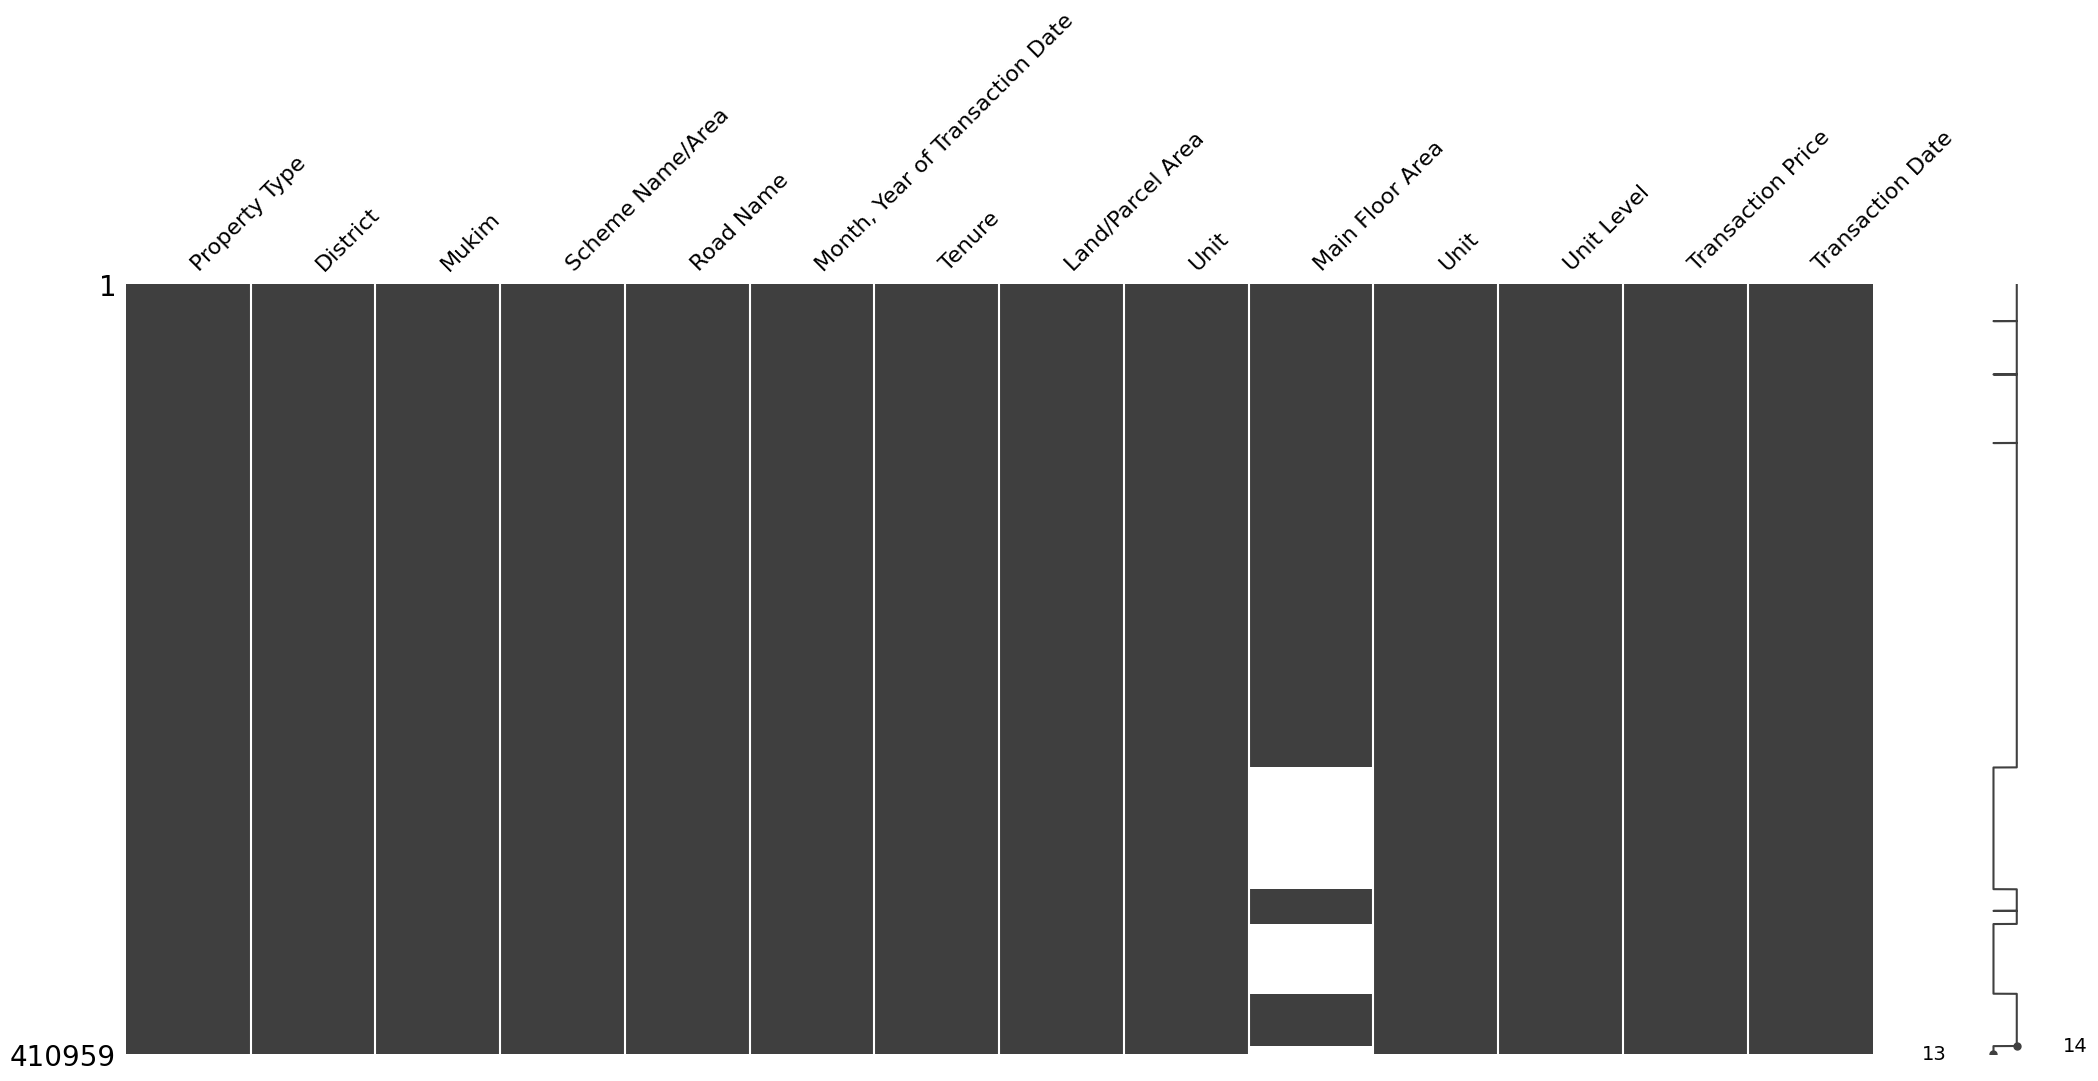

In [28]:
msno.matrix(df)  # visualizing missing numeric data with Matrix plot (missingno library)

**Handle missing values**

In [29]:
# Handle missing values in 'Main Floor Area' by filling with the median
df['Main Floor Area'] = df['Main Floor Area'].fillna(df['Main Floor Area'].median())

<Axes: >

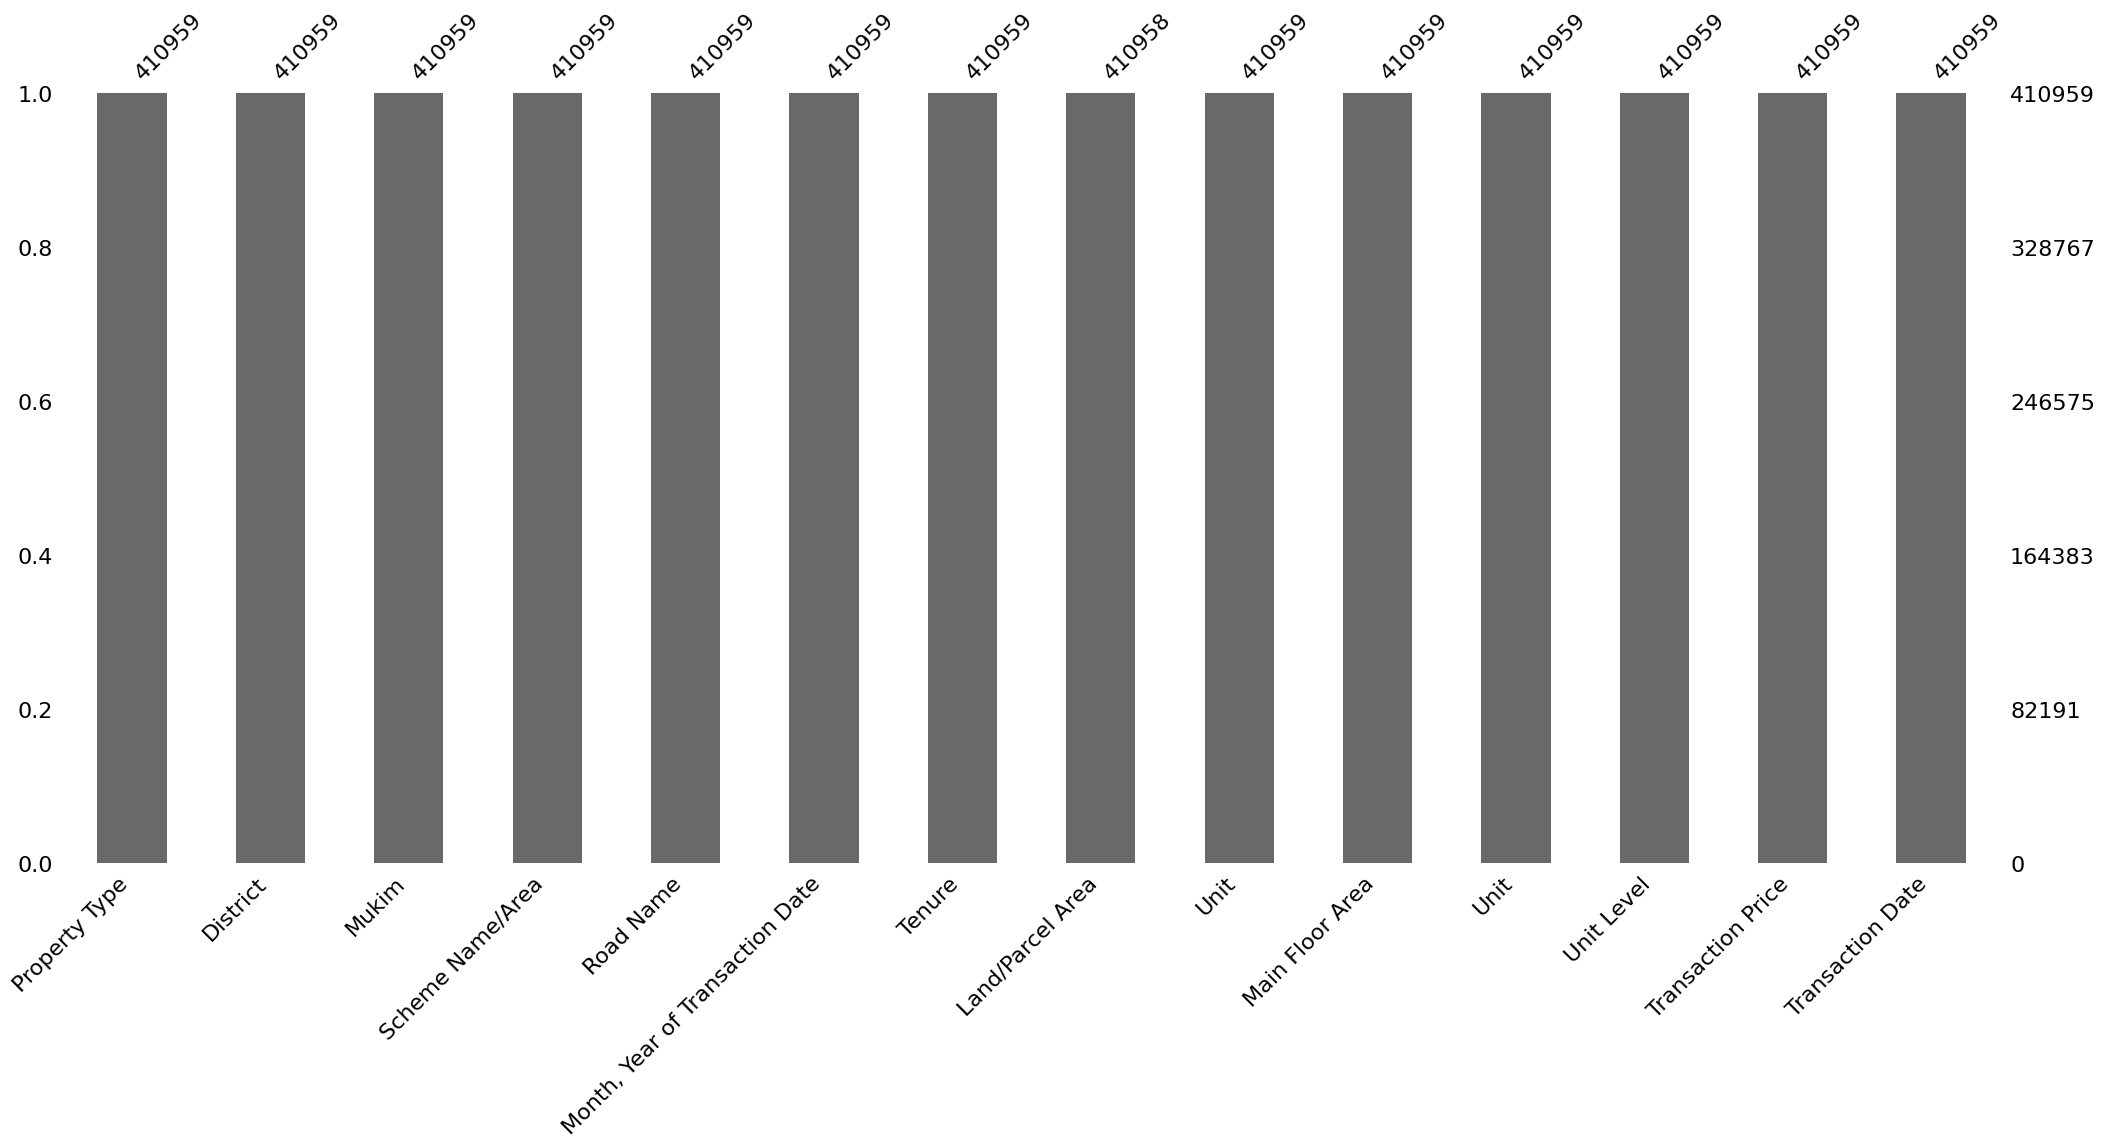

In [30]:
msno.bar(df)

<Axes: >

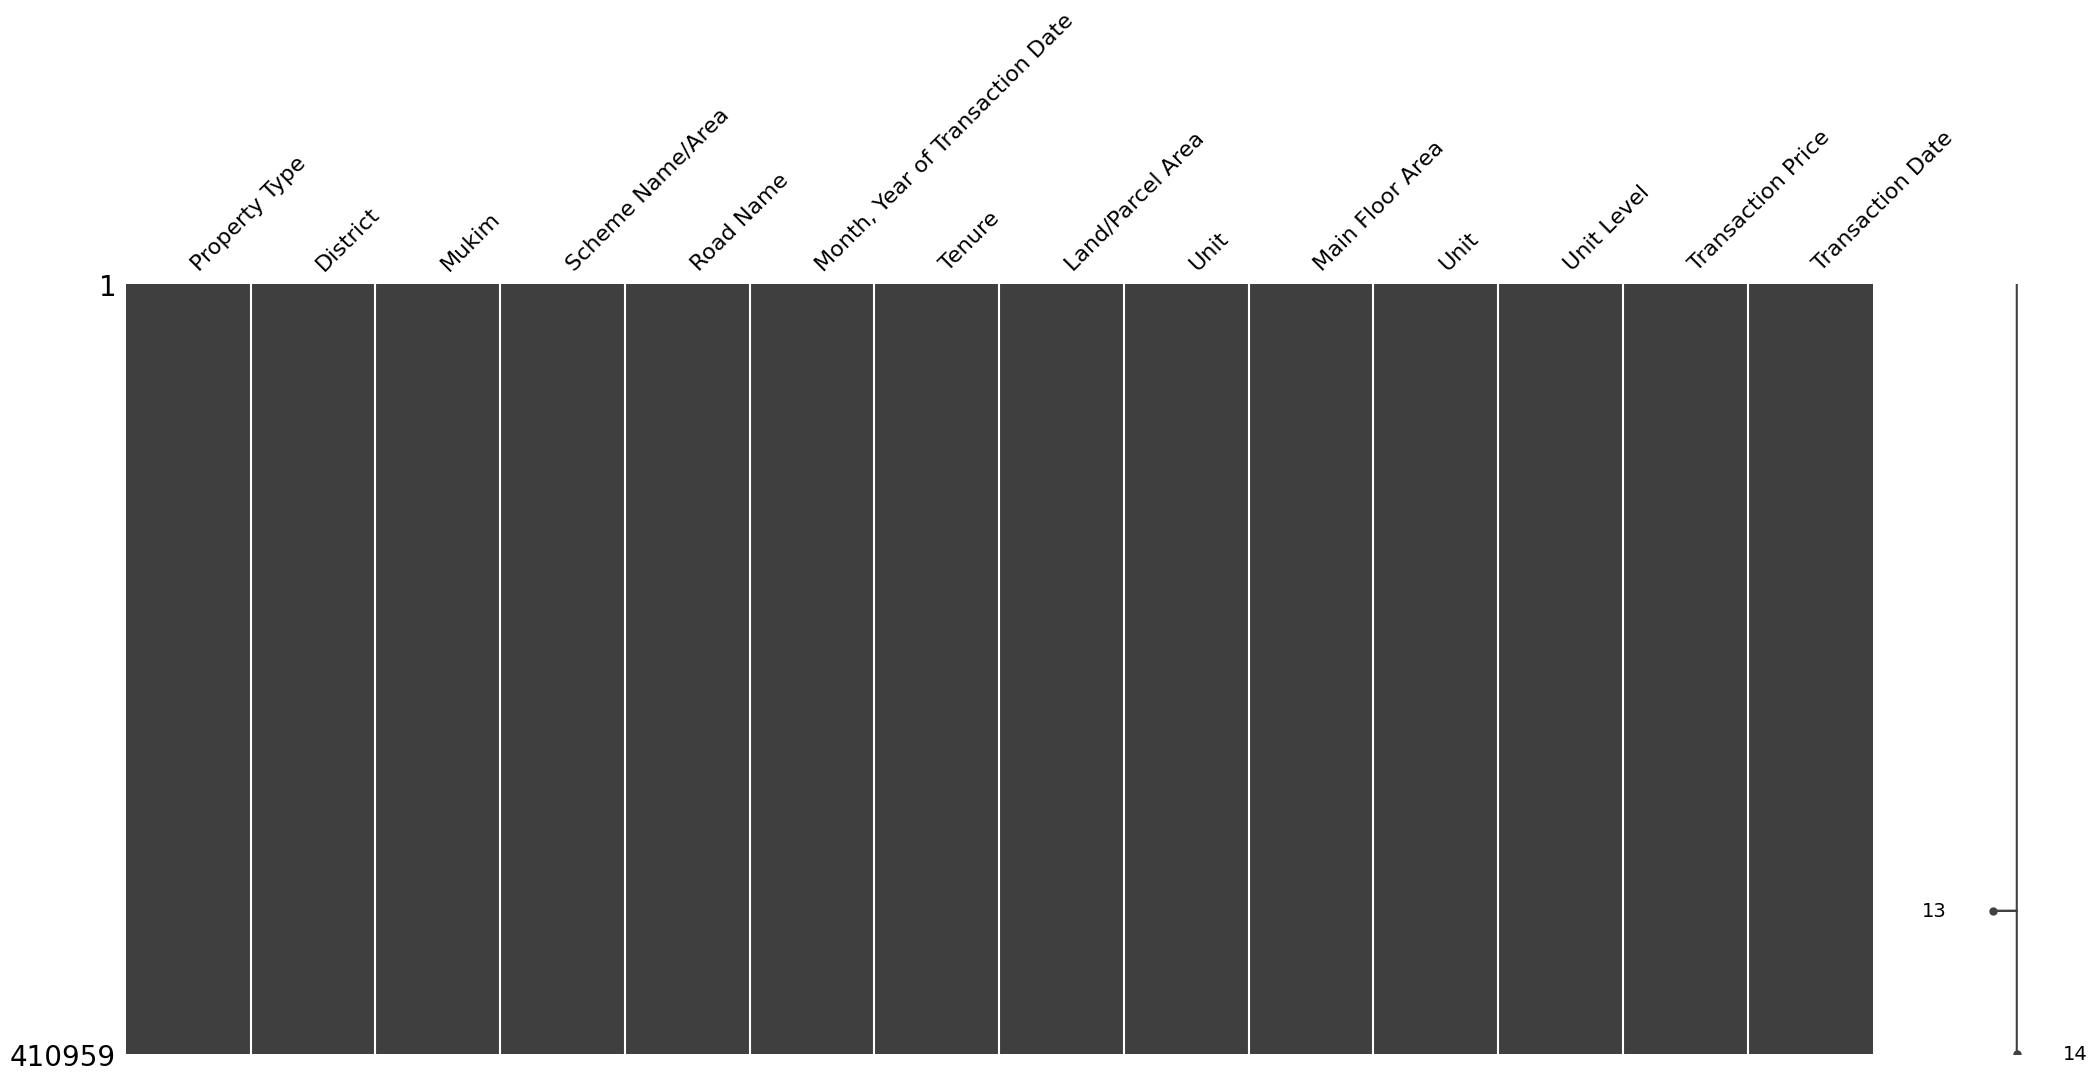

In [31]:
msno.matrix(df) 

**Johor Property Analysis**

In [32]:
# List of districts in Johor
johor_districts = ['Johor Bahru', 'Batu Pahat', 'Kluang', 'Kota Tinggi', 'Kulai', 'Mersing', 'Muar', 'Pontian', 'Segamat', 'Tangkak']

# Filter the dataframe for Johor districts
df_johor = df[df['District'].isin(johor_districts)]

# Aggregate by District: count the number of properties per district
district_counts = df_johor.groupby('District').size()
print(district_counts)

District
Batu Pahat      4530
Johor Bahru    45701
Kluang          5351
Kota Tinggi     2788
Kulai           6267
Mersing          310
Muar            2748
Pontian         1303
Segamat         2122
Tangkak         1658
dtype: int64


            Transaction Price                                            \
                        count       mean    median      min         max   
District                                                                  
Batu Pahat               4530  395376.82  368000.0  30000.0   1899000.0   
Johor Bahru             45701  580085.32  498000.0  22000.0  13800000.0   
Kluang                   5351  355108.39  300000.0  25000.0   2631000.0   
Kota Tinggi              2788  375943.33  356000.0  42000.0   1575000.0   
Kulai                    6267  487571.25  443000.0  22000.0   3051000.0   
Mersing                   310  257441.94  253000.0  40000.0    780000.0   
Muar                     2748  499437.41  440000.0  42000.0   3000000.0   
Pontian                  1303  449125.86  440000.0  38000.0   1200000.0   
Segamat                  2122  283368.05  271500.0  25000.0   1100000.0   
Tangkak                  1658  388833.53  388000.0  22000.0   1300000.0   

            Main Floor A

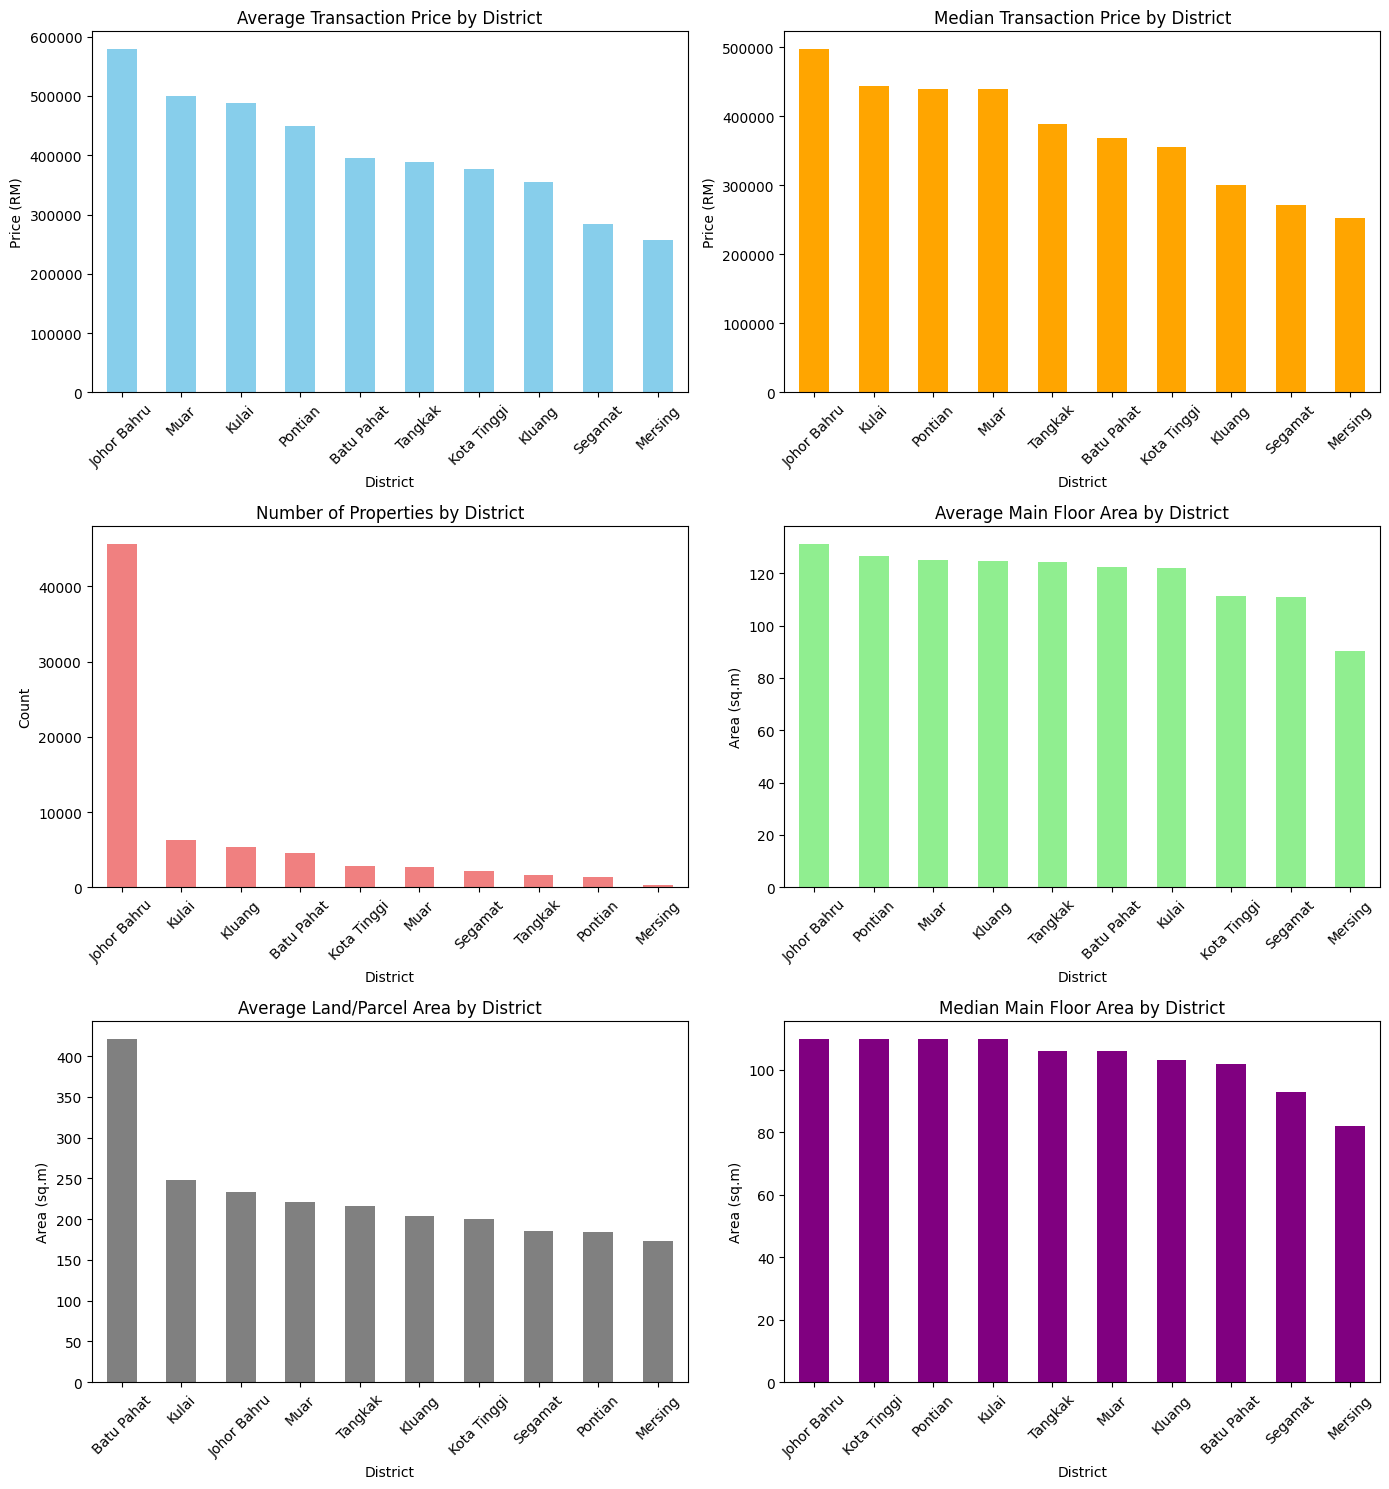

In [36]:
# Create a comparison table of all districts
district_comparison = df_johor.groupby('District').agg({
    'Transaction Price': ['count', 'mean', 'median', 'min', 'max'],
    'Main Floor Area': ['mean', 'median'],
    'Land/Parcel Area': ['mean', 'median']
}).round(2)

print(district_comparison)

# Visualize the comparison
fig, axes = plt.subplots(3, 2, figsize=(14, 15))

# Average Transaction Price by District
df_johor.groupby('District')['Transaction Price'].mean().sort_values(ascending=False).plot(kind='bar', ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Average Transaction Price by District')
axes[0, 0].set_ylabel('Price (RM)')
axes[0, 0].tick_params(axis='x', rotation=45)

# Median Transaction Price by District
df_johor.groupby('District')['Transaction Price'].median().sort_values(ascending=False).plot(kind='bar', ax=axes[0, 1], color='orange')
axes[0, 1].set_title('Median Transaction Price by District')
axes[0, 1].set_ylabel('Price (RM)')
axes[0, 1].tick_params(axis='x', rotation=45)

# Number of Properties by District
district_counts.sort_values(ascending=False).plot(kind='bar', ax=axes[1, 0], color='lightcoral')
axes[1, 0].set_title('Number of Properties by District')
axes[1, 0].set_ylabel('Count')
axes[1, 0].tick_params(axis='x', rotation=45)

# Average Main Floor Area by District
df_johor.groupby('District')['Main Floor Area'].mean().sort_values(ascending=False).plot(kind='bar', ax=axes[1, 1], color='lightgreen')
axes[1, 1].set_title('Average Main Floor Area by District')
axes[1, 1].set_ylabel('Area (sq.m)')
axes[1, 1].tick_params(axis='x', rotation=45)

# Average Land/Parcel Area by District
df_johor.groupby('District')['Land/Parcel Area'].mean().sort_values(ascending=False).plot(kind='bar', ax=axes[2, 0], color='grey')
axes[2, 0].set_title('Average Land/Parcel Area by District')
axes[2, 0].set_ylabel('Area (sq.m)')
axes[2, 0].tick_params(axis='x', rotation=45)

# Median Main Floor Area by District (for completeness)
df_johor.groupby('District')['Main Floor Area'].median().sort_values(ascending=False).plot(kind='bar', ax=axes[2, 1], color='purple')
axes[2, 1].set_title('Median Main Floor Area by District')
axes[2, 1].set_ylabel('Area (sq.m)')
axes[2, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Bivarate & Multivariate Analysis**

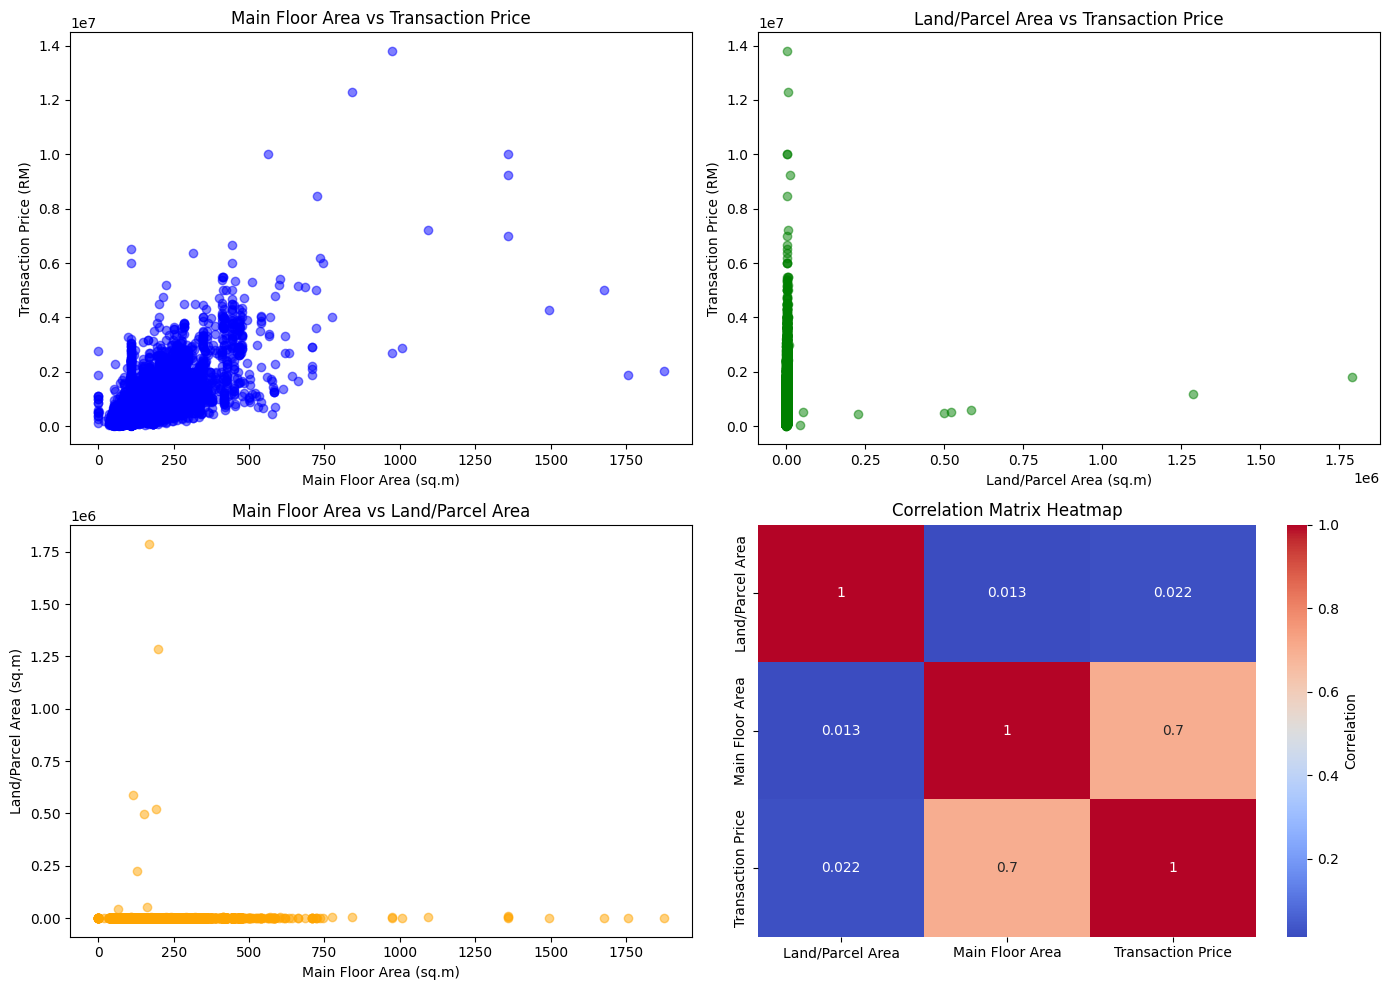

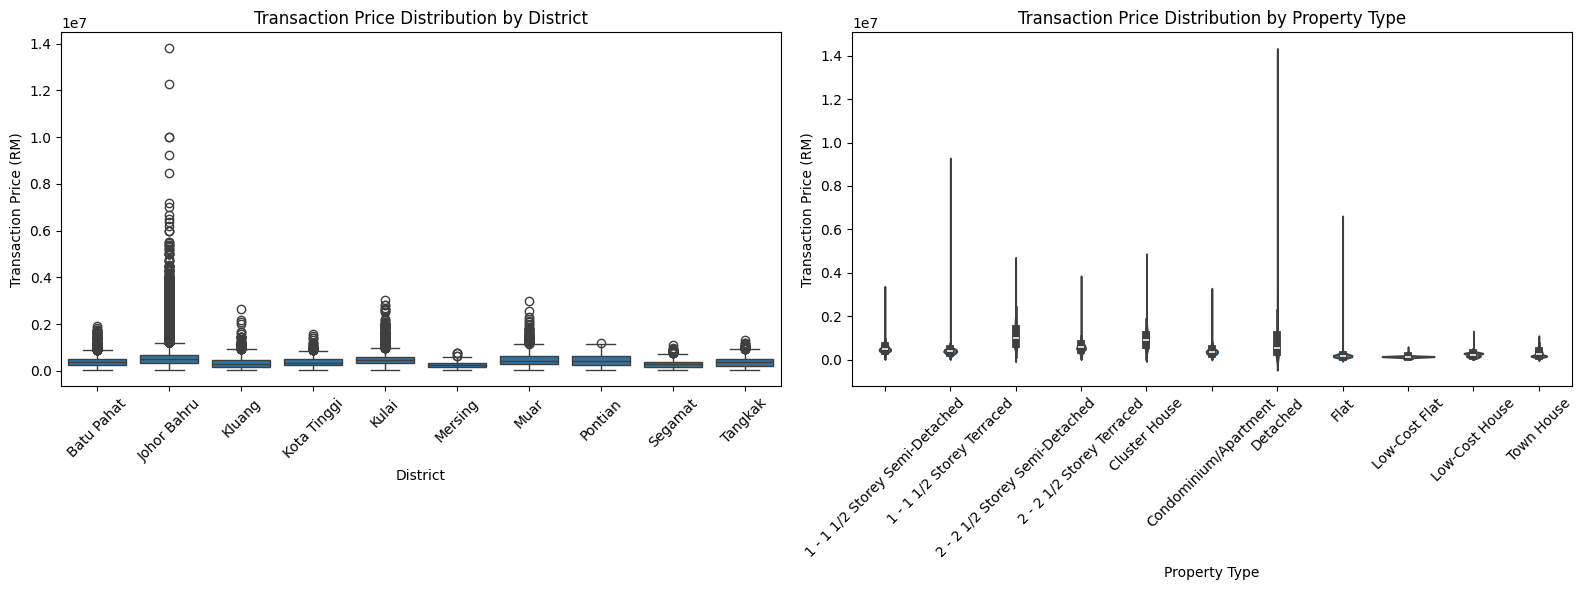


Multivariate Summary (by District and Tenure):
                      Transaction Price                  Main Floor Area  \
                                   mean    median  count            mean   
District    Tenure                                                         
Batu Pahat  Freehold          397111.97  370000.0   4421          122.47   
            Leasehold         325000.00  230000.0    109          123.06   
Johor Bahru Freehold          611603.54  520000.0  39328          134.05   
            Leasehold         385585.28  350000.0   6373          114.92   
Kluang      Freehold          367499.07  308000.0   4825          128.46   
            Leasehold         241448.67  200000.0    526           90.19   
Kota Tinggi Freehold          424367.16  403000.0   1212          121.35   
            Leasehold         338703.68  320000.0   1576          103.45   
Kulai       Freehold          490703.58  450000.0   5762          120.56   
            Leasehold         451831.68 

In [42]:
# Bivariate Analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Scatter plot: Main Floor Area vs Transaction Price
axes[0, 0].scatter(df_johor['Main Floor Area'], df_johor['Transaction Price'], alpha=0.5, color='blue')
axes[0, 0].set_xlabel('Main Floor Area (sq.m)')
axes[0, 0].set_ylabel('Transaction Price (RM)')
axes[0, 0].set_title('Main Floor Area vs Transaction Price')

# Scatter plot: Land/Parcel Area vs Transaction Price
axes[0, 1].scatter(df_johor['Land/Parcel Area'], df_johor['Transaction Price'], alpha=0.5, color='green')
axes[0, 1].set_xlabel('Land/Parcel Area (sq.m)')
axes[0, 1].set_ylabel('Transaction Price (RM)')
axes[0, 1].set_title('Land/Parcel Area vs Transaction Price')

# Scatter plot: Main Floor Area vs Land/Parcel Area
axes[1, 0].scatter(df_johor['Main Floor Area'], df_johor['Land/Parcel Area'], alpha=0.5, color='orange')
axes[1, 0].set_xlabel('Main Floor Area (sq.m)')
axes[1, 0].set_ylabel('Land/Parcel Area (sq.m)')
axes[1, 0].set_title('Main Floor Area vs Land/Parcel Area')

# Correlation heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', ax=axes[1, 1], cbar_kws={'label': 'Correlation'})
axes[1, 1].set_title('Correlation Matrix Heatmap')

plt.tight_layout()
plt.show()

# Multivariate Analysis: Transaction Price by District and Property Type
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Box plot: Transaction Price by District
sns.boxplot(data=df_johor, x='District', y='Transaction Price', ax=axes[0])
axes[0].set_title('Transaction Price Distribution by District')
axes[0].set_xlabel('District')
axes[0].set_ylabel('Transaction Price (RM)')
axes[0].tick_params(axis='x', rotation=45)

# Violin plot: Transaction Price by Property Type
sns.violinplot(data=df_johor, x='Property Type', y='Transaction Price', ax=axes[1])
axes[1].set_title('Transaction Price Distribution by Property Type')
axes[1].set_xlabel('Property Type')
axes[1].set_ylabel('Transaction Price (RM)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Multivariate summary: Average metrics by District and Tenure
multivariate_summary = df_johor.groupby(['District', 'Tenure']).agg({
    'Transaction Price': ['mean', 'median', 'count'],
    'Main Floor Area': 'mean',
    'Land/Parcel Area': 'mean'
}).round(2)

print("\nMultivariate Summary (by District and Tenure):")
print(multivariate_summary)